In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import plotly.graph_objects as go
import plotly.express as px

# Load Data With The Help Of The `PANDAS OR OS`

In [2]:
batch = os.getcwd()
try:
    path_data = os.path.join(batch, '..', 'data/house_price.csv')
    df = pd.read_csv(path_data)
except:
    print('fix the data path than next move on....')



In [3]:
df.head()

,Size_sqft,Lot_Size_sqft,Living_Area_sqft,Basement_Area_sqft,Garage_Area_sqft,Bedrooms,Bathrooms,Full_Baths,Half_Baths,Total_Rooms,...,Annual_HOA_Fees,Property_Tax_Rate,Month_Sold,Year_Sold,View_Score,Fence_Quality,Roof_Age_years,Driveway_Paved,Electric_System_Type,Price_USD
0,2020,9317,1564,0,240,5,1.0,1,0,10,...,0,3.15,11,2025,1,3,22,1,2,679258
1,1337,16962,1245,0,789,3,2.0,2,0,8,...,0,1.46,4,2024,5,3,11,0,1,588149
2,3350,16299,2537,624,568,4,3.5,3,1,11,...,2434,1.63,6,2025,3,2,18,1,3,722022
3,1719,14180,1509,0,396,1,1.5,1,1,4,...,0,1.16,4,2022,3,3,6,1,2,539798
4,2172,16362,1948,0,345,5,1.5,1,1,7,...,4201,1.32,11,2022,1,3,0,1,2,736439


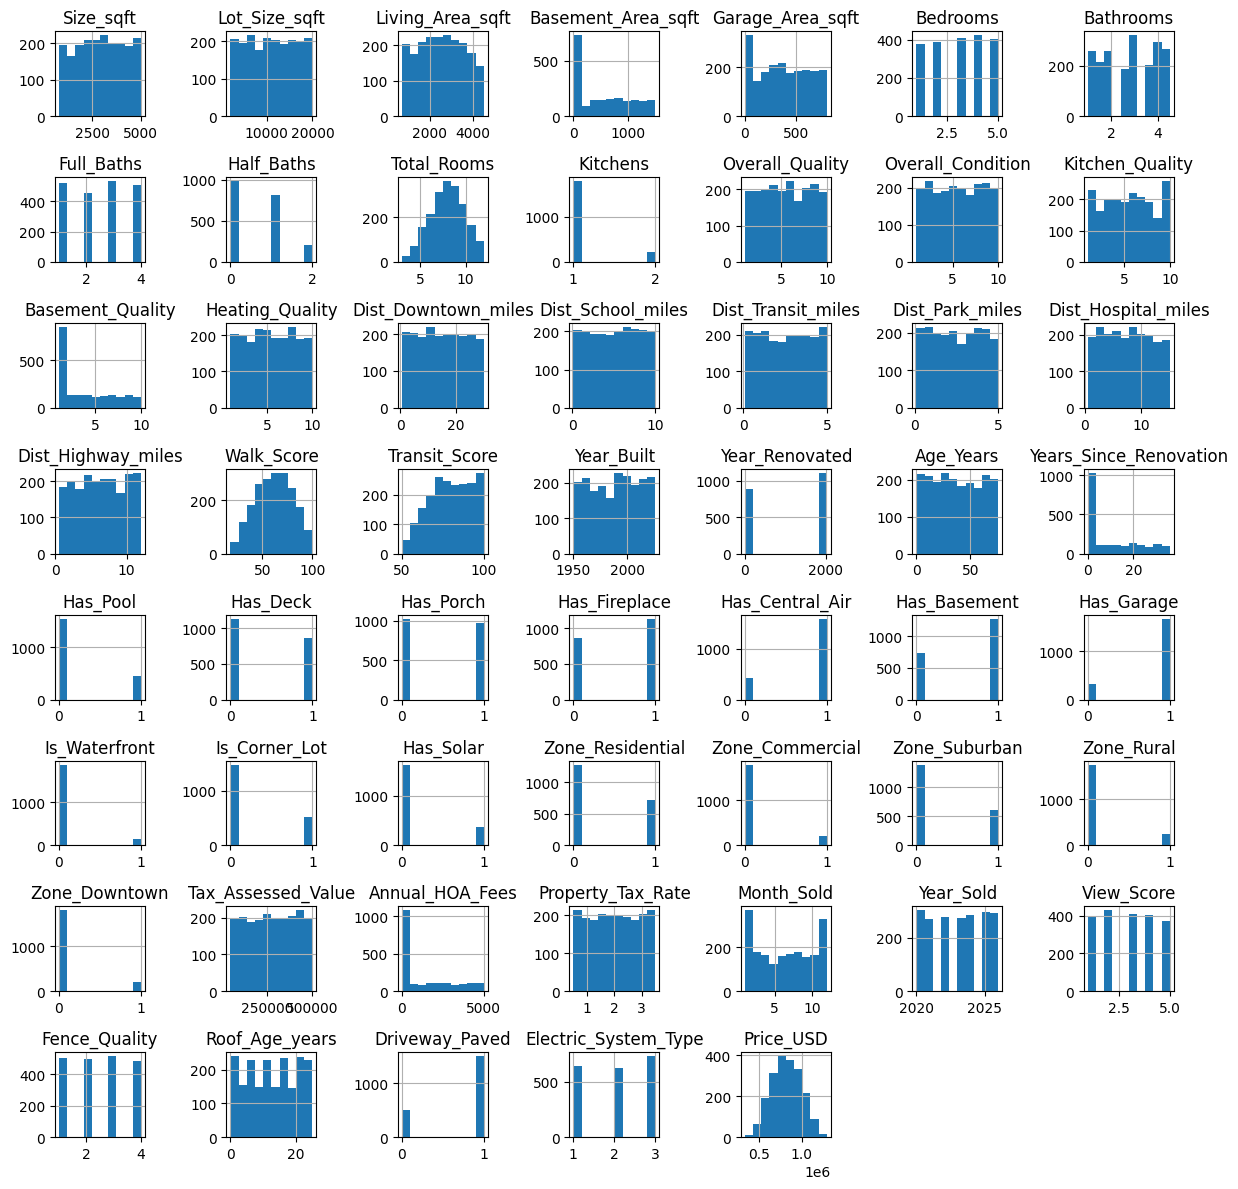

In [4]:
df.hist(figsize=(12,12))
plt.tight_layout()

## clean the data

In [5]:
print('this is info for the data')
df.info()

this is info for the data
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 54 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Size_sqft               2000 non-null   int64  
 1   Lot_Size_sqft           2000 non-null   int64  
 2   Living_Area_sqft        2000 non-null   int64  
 3   Basement_Area_sqft      2000 non-null   int64  
 4   Garage_Area_sqft        2000 non-null   int64  
 5   Bedrooms                2000 non-null   int64  
 6   Bathrooms               2000 non-null   float64
 7   Full_Baths              2000 non-null   int64  
 8   Half_Baths              2000 non-null   int64  
 9   Total_Rooms             2000 non-null   int64  
 10  Kitchens                2000 non-null   int64  
 11  Overall_Quality         2000 non-null   int64  
 12  Overall_Condition       2000 non-null   int64  
 13  Kitchen_Quality         2000 non-null   int64  
 14  Basement_Quali

In [6]:
# null value checking or one advantages is all in numerice val
df_cleaned = df.copy()

null_val_count = df.isnull().sum()
if null_val_count.sum() != 0:
     if len(df.select_dtypes('object').columns) == 0:
          num_col = df.select_dtypes(['int64','float64']).columns
          df_cleaned[num_col] = df[num_col].fillna(df[num_col].median())
     else:
          cat_col = df.select_dtypes(['object']).columns
          num_col = df.select_dtypes(['int64','float64']).columns
          df_cleaned[num_col] = df[num_col].fillna(df[num_col].median())
          df_cleaned[cat_col] = df[cat_col].fillna(df[cat_col].mode().iloc[0])
else:
     print('all cleaned')
          
          

all cleaned


## data spliting


In [7]:
X, y = df.drop('Price_USD', axis=1), df['Price_USD'] 

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scale = StandardScaler()
X_train_scale = scale.fit_transform(X_train) 
X_test_scale = scale.transform(X_test) 

# Find top 3 model used in house prediction

## neruall network model

In [9]:
from tensorflow.keras.layers import Dense
import tensorflow as tf

In [10]:
class HousePriceNN(tf.keras.Model):
    def __init__(self):
        super(HousePriceNN, self).__init__()
        self.dense1 = Dense(128, activation="relu")
        self.dense2 = Dense(128, activation="relu")
        self.dense3 = Dense(64, activation="relu")
        self.dense4 = Dense(32, activation="relu")
        self.dense5 = Dense(16, activation="relu")
        self.output_layer = Dense(1)

    def call(self, inputs):
        x = self.dense1(inputs)
        x = self.dense2(x)
        x = self.dense3(x)
        x = self.dense4(x)
        x = self.dense5(x)
        return self.output_layer(x)

# Create model
nerual_model = HousePriceNN()

In [11]:
nerual_model.build(input_shape=(None, X_train_scale.shape[1]))

# Compile
nerual_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

# Train
nerual_model.fit(
    X_train_scale,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2
)

c:\Users\sumit\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\layer.py:427: UserWarning: `build()` was called on layer 'house_price_nn', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 702078058496.0000 - mae: 819340.7500 - val_loss: 715238735872.0000 - val_mae: 830062.8750
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 701420470272.0000 - mae: 818945.8750 - val_loss: 712808267776.0000 - val_mae: 828627.9375
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 688088678400.0000 - mae: 811047.5625 - val_loss: 676642553856.0000 - val_mae: 807197.5625
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 573252960256.0000 - mae: 738700.1875 - val_loss: 441815826432.0000 - val_mae: 651979.8125
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 190590976000.0000 - mae: 389839.5625 - val_loss: 32456841216.0000 - val_mae: 148033.4688
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 15554322432.0000 - mae: 98754.8203 - val_loss: 15824958464.0000 - val_mae: 102055.0469
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8199512064.0000 - mae: 72229.5859 - val_loss: 1064

In [12]:
nerual_model.save('bulided_model/nerual_model.keras')

In [13]:
54761.2930/(y.max()-y.min()) * 100

np.float64(5.667955588952508)

### | Error % | Quality     |
    | ------- | ----------- |
    | < 5%    | Excellent ⭐ |
    | 5–10%   | Very Good ✅ |
    | 10–15%  | Good 👍     |
    | 15–20%  | Fair ⚠️     |
    | 20–30%  | Weak ❌      |
    | > 30%   | Poor 🚨     |


In [14]:


predictions = nerual_model.predict(X_test_scale)

r2 = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = root_mean_squared_error(y_test, predictions) 

print("R² Score:", r2)
print(f"MAE: {(mae/(y.max()-y.min()) * 100):.2f}")
print(f"RMSE: {(rmse/(y.max()-y.min()) * 100):.2f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
R² Score: 0.8610482215881348
MAE: 5.39
RMSE: 6.75


### chartrs for showing model accuracy 


In [15]:


predictions = nerual_model.predict(X_test_scale).flatten()

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        y=y_test.values[:50],
        mode="lines",
        name="Actual"
    )
)

fig.add_trace(
    go.Scatter(
        y=predictions[:50],
        mode="lines",
        name="Predicted"
    )
)

fig.update_layout(
    title="Actual vs Predicted House Prices",
    xaxis_title="Sample",
    yaxis_title="Price"
)

fig.show()

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


## bulided model

In [16]:
models = {
    "Linear Regression": LinearRegression(),
         

    "dt":DecisionTreeRegressor(),
 
   
    "Random Forest": RandomForestRegressor(n_estimators=400),
    
    
    "KNN": KNeighborsRegressor( ),

    "Lasso": Lasso(),
    
    "Ridge": Ridge(),

    "XGBoost": XGBRegressor(
        n_estimators=100 
    ),

}

In [17]:
import joblib

results = {}
best_model_name = None
best_r2 = 0

for name, model in models.items():

    print(f"\n{'─'*50}")
    print(f"Model: {name}")
    print(f"{'─'*50}")

    # =========================
    # TRAIN
    # =========================
    model.fit(X_train_scale, y_train)
    joblib.dump(model, f"bulided_model/{name}_model.pkl")


    # =========================
    # PREDICT
    # =========================
    predictions = model.predict(X_test_scale)


    # =========================
    # Evaluate
    # =========================
    r2 = r2_score(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = root_mean_squared_error(y_test, predictions)
    mape = mean_absolute_percentage_error(y_test, predictions)

    results[name] = {
        'r2_socre': r2,
        'mae' : mae,
        'mse' : mse,
        'rmse': rmse,
        'mape': mape
    }

    if r2 > best_r2:
        best_r2 = r2
        best_model_name = name
    
    print("R² Score:", r2)
    print(f"MAE: {(mae/(y.max()-y.min()) * 100):.2f}")
    print(f"RMSE: {(rmse/(y.max()-y.min()) * 100):.2f}")
    print(f'mape: {mape :.2f}')
    
print("\n" + "="*60)
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"AUC Score   : {best_r2:.4f}")
print("="*60)



──────────────────────────────────────────────────
Model: Linear Regression
──────────────────────────────────────────────────
R² Score: 0.9334660019891986
MAE: 3.53
RMSE: 4.67
mape: 0.04

──────────────────────────────────────────────────
Model: dt
──────────────────────────────────────────────────
R² Score: 0.6608488874355691
MAE: 8.38
RMSE: 10.55
mape: 0.10

──────────────────────────────────────────────────
Model: Random Forest
──────────────────────────────────────────────────
R² Score: 0.8804476989005047
MAE: 4.95
RMSE: 6.26
mape: 0.06

──────────────────────────────────────────────────
Model: KNN
──────────────────────────────────────────────────
R² Score: 0.5528490905177813
MAE: 9.69
RMSE: 12.11
mape: 0.12

──────────────────────────────────────────────────
Model: Lasso
──────────────────────────────────────────────────
R² Score: 0.9334638356678004
MAE: 3.53
RMSE: 4.67
mape: 0.04

──────────────────────────────────────────────────
Model: Ridge
─────────────────────────────────

In [18]:
print(best_model_name)

Linear Regression


## better fearure according best model 

In [19]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X, y)

importance = rf.feature_importances_

selected_rsfs = X.columns[importance > np.mean(importance)]
print("RSFS Selected:", selected_rsfs)

c:\Users\sumit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_forest.py:830: UserWarning:

The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.

c:\Users\sumit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning:

The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.

c:\Users\sumit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning:

The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.

c:\Users\sumit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning:

The number of unique classes is greater than 50% of the number of samples. `y` could 

RSFS Selected: Index(['Size_sqft', 'Lot_Size_sqft', 'Living_Area_sqft', 'Basement_Area_sqft',
       'Garage_Area_sqft', 'Total_Rooms', 'Overall_Quality',
       'Overall_Condition', 'Kitchen_Quality', 'Heating_Quality',
       'Dist_Downtown_miles', 'Dist_School_miles', 'Dist_Transit_miles',
       'Dist_Park_miles', 'Dist_Hospital_miles', 'Dist_Highway_miles',
       'Walk_Score', 'Transit_Score', 'Year_Built', 'Year_Renovated',
       'Age_Years', 'Years_Since_Renovation', 'Tax_Assessed_Value',
       'Annual_HOA_Fees', 'Property_Tax_Rate', 'Month_Sold', 'Roof_Age_years'],
      dtype='object')


In [20]:
print(selected_rsfs)

Index(['Size_sqft', 'Lot_Size_sqft', 'Living_Area_sqft', 'Basement_Area_sqft',
       'Garage_Area_sqft', 'Total_Rooms', 'Overall_Quality',
       'Overall_Condition', 'Kitchen_Quality', 'Heating_Quality',
       'Dist_Downtown_miles', 'Dist_School_miles', 'Dist_Transit_miles',
       'Dist_Park_miles', 'Dist_Hospital_miles', 'Dist_Highway_miles',
       'Walk_Score', 'Transit_Score', 'Year_Built', 'Year_Renovated',
       'Age_Years', 'Years_Since_Renovation', 'Tax_Assessed_Value',
       'Annual_HOA_Fees', 'Property_Tax_Rate', 'Month_Sold', 'Roof_Age_years'],
      dtype='object')


In [21]:
from sklearn.ensemble import RandomForestClassifier

rf = XGBRegressor()
rf.fit(X, y)

importance = rf.feature_importances_

selected_rsfs = X.columns[importance > np.mean(importance)]
print("RSFS Selected:", selected_rsfs)

RSFS Selected: Index(['Size_sqft', 'Living_Area_sqft', 'Full_Baths', 'Overall_Quality',
       'Kitchen_Quality', 'Is_Waterfront', 'Zone_Downtown',
       'Tax_Assessed_Value'],
      dtype='object')


In [47]:
X_train, X_test , y_train, y_test = train_test_split(df_cleaned[selected_rsfs], y, test_size=0.3, random_state=42)
scale = StandardScaler()
X_train, X_test = scale.fit_transform(X_train), scale.transform(X_test)

In [48]:

results = {}
best_model_name = None
best_r2 = 0

for name, model in models.items():

    print(f"\n{'─'*50}")
    print(f"Model: {name}")
    print(f"{'─'*50}")

    # =========================
    # TRAIN
    # =========================
    model.fit(X_train, y_train)


    # =========================
    # PREDICT
    # =========================
    predictions = model.predict(X_test)
    joblib.dump(model, f"bulided_model_slected_feature/{name}_model.pkl")


    # =========================
    # Evaluate
    # =========================
    r2 = r2_score(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = root_mean_squared_error(y_test, predictions)

    results[name] = {
        'r2_socre': r2,
        'mae' : mae,
        'mse' : mse,
        'rmse': rmse
    }

    if r2 > best_r2:
        best_r2 = r2
        best_model_name = name
    
    print("R² Score:", r2)
    print(f"MAE: {(mae/(y.max()-y.min()) * 100):.2f}")
    print(f"RMSE: {(rmse/(y.max()-y.min()) * 100):.2f}")
    
print("\n" + "="*60)
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"AUC Score   : {best_r2:.4f}")
print("="*60)



──────────────────────────────────────────────────
Model: Linear Regression
──────────────────────────────────────────────────
R² Score: 0.8849654327598405
MAE: 4.76
RMSE: 6.06

──────────────────────────────────────────────────
Model: dt
──────────────────────────────────────────────────
R² Score: 0.6955315403309901
MAE: 7.81
RMSE: 9.85

──────────────────────────────────────────────────
Model: Random Forest
──────────────────────────────────────────────────
R² Score: 0.8619828358527872
MAE: 5.25
RMSE: 6.64

──────────────────────────────────────────────────
Model: KNN
──────────────────────────────────────────────────
R² Score: 0.84221423613741
MAE: 5.71
RMSE: 7.09

──────────────────────────────────────────────────
Model: Lasso
──────────────────────────────────────────────────
R² Score: 0.8849677388517699
MAE: 4.76
RMSE: 6.06

──────────────────────────────────────────────────
Model: Ridge
──────────────────────────────────────────────────
R² Score: 0.8849298045939121
MAE: 4.76
RM

In [43]:
from sklearn.linear_model import LinearRegression
import pandas as pd

model = LinearRegression()
model.fit(X_train, y_train)

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_
})

importance["Absolute_Importance"] = abs(importance["Coefficient"])
importance = importance.sort_values(
    by="Absolute_Importance",
    ascending=False
)

print(importance)

                   Feature   Coefficient  Absolute_Importance
35           Is_Waterfront  54114.427911         54114.427911
42           Zone_Downtown  46970.616143         46970.616143
6                Bathrooms  26105.661145         26105.661145
28                Has_Pool  18530.710368         18530.710368
11         Overall_Quality  17216.958038         17216.958038
41              Zone_Rural -14935.358483         14935.358483
40           Zone_Suburban -13470.007167         13470.007167
39         Zone_Commercial -12281.334839         12281.334839
5                 Bedrooms  11673.298482         11673.298482
37               Has_Solar   9956.006503          9956.006503
34              Has_Garage   8872.153706          8872.153706
48              View_Score   8066.175897          8066.175897
7               Full_Baths  -7591.203283          7591.203283
8               Half_Baths  -6286.068486          6286.068486
38        Zone_Residential  -6283.915654          6283.915654
13      